# 01 · Data Exploration — Project Wafa
Class balance, churn rate by segment/region, language mix.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
from src import config
from src.utils import load_json
msgs=pd.read_csv(config.MESSAGES_CSV); cust=pd.read_csv(config.CUSTOMERS_CSV)
print(msgs.shape, cust.shape); msgs.head()

(252, 6) (240, 14)


,message_id,customer_id,text,language,issue_type,churn_signal
0,M0166,FB1195,mera card foreign mein decline ho gaya. main s...,hi,Card_Services,Medium
1,M0007,FB1186,how do I close my salary account. I have alrea...,en,Account_Closure,High
2,M0112,FB1069,We are relocating for good. refund the hidden ...,en,Fees_Charges,High
3,M0173,FB1159,my card was declined abroad. Just checking.,en,Card_Services,Low
4,M0116,FB1097,We are relocating for good. these charges are ...,en,Fees_Charges,High


## Message class balance

In [2]:
print('Languages:\n', msgs.language.value_counts())
print('\nIssue types:\n', msgs.issue_type.value_counts())
print('\nChurn signals:\n', msgs.churn_signal.value_counts())

Languages:
 language
en    138
ar     47
tl     38
hi     29
Name: count, dtype: int64

Issue types:
 issue_type
Card_Services          36
Account_Closure        36
Fees_Charges           36
App_Technical          36
General_Query          36
Remittance_Transfer    36
Loan_Mortgage          36
Name: count, dtype: int64

Churn signals:
 churn_signal
Medium    84
High      84
Low       84
Name: count, dtype: int64


## Customer churn rate by segment & region

In [3]:
cust['churned']=cust.churned.astype(str).str.lower().isin(['true','1'])
print('Overall churn rate:', round(cust.churned.mean(),3))
print('\nBy segment:\n', cust.groupby('segment').churned.mean().round(3))
print('\nBy region:\n', cust.groupby('nationality_region').churned.mean().round(3))

Overall churn rate: 0.288

By segment:
 segment
Mass       0.268
Premium    0.343
Private    0.238
Name: churned, dtype: float64

By region:
 nationality_region
East_Asia         0.364
MENA              0.233
South_Asia        0.286
Southeast_Asia    0.341
Western           0.233
Name: churned, dtype: float64


## Quick plots

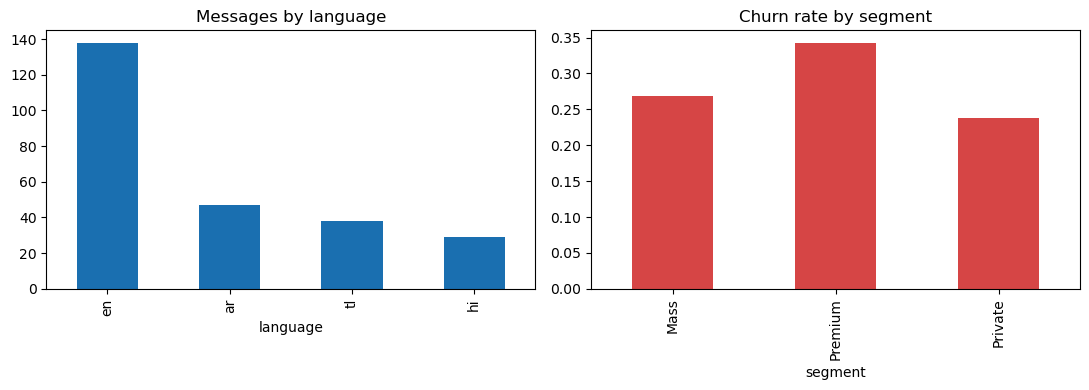

In [4]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(11,4))
msgs.language.value_counts().plot.bar(ax=ax[0],title='Messages by language',color='#1a6fb0')
cust.groupby('segment').churned.mean().plot.bar(ax=ax[1],title='Churn rate by segment',color='#d64545')
plt.tight_layout(); plt.show()